In [ ]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('ggplot')

Matplotlib is building the font cache; this may take a moment.


In [ ]:
#Create dataset
np.random.seed(42)

n = 500

square_feet = np.random.randint(800, 5000, n)
bedrooms = np.random.randint(1, 7, n)
bathrooms = np.random.randint(1, 5, n)

price = (
    square_feet * 180
    + bedrooms * 15000
    + bathrooms * 12000
    + np.random.randint(-50000, 50000, n)
)

df = pd.DataFrame({
    'SquareFeet': square_feet,
    'Bedrooms': bedrooms,
    'Bathrooms': bathrooms,
    'Price': price
})

df.head()

,SquareFeet,Bedrooms,Bathrooms,Price
0,1660,1,1,300374
1,4572,3,3,857390
2,3892,4,2,747236
3,1266,2,3,254696
4,4244,6,3,872653


In [ ]:
#dataset overview 
print("Dataset Shape:", df.shape)

display(df.head())

df.info()

display(df.describe())


Dataset Shape: (500, 4)


,SquareFeet,Bedrooms,Bathrooms,Price
0,1660,1,1,300374
1,4572,3,3,857390
2,3892,4,2,747236
3,1266,2,3,254696
4,4244,6,3,872653


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   SquareFeet  500 non-null    int64
 1   Bedrooms    500 non-null    int64
 2   Bathrooms   500 non-null    int64
 3   Price       500 non-null    int64
dtypes: int64(4)
memory usage: 15.8 KB


,SquareFeet,Bedrooms,Bathrooms,Price
count,500.000000,500.000000,500.000000,5.000000e+02
mean,2989.916000,3.554000,2.432000,6.207600e+05
std,1184.261381,1.745043,1.093512,2.175103e+05
min,804.000000,1.000000,1.000000,2.067670e+05
25%,1953.000000,2.000000,1.000000,4.258398e+05
50%,3046.000000,4.000000,2.000000,6.277040e+05
75%,3993.750000,5.000000,3.000000,8.095885e+05
max,4999.000000,6.000000,4.000000,1.036536e+06


In [ ]:
#missing values 
print(df.isnull().sum())

SquareFeet    0
Bedrooms      0
Bathrooms     0
Price         0
dtype: int64


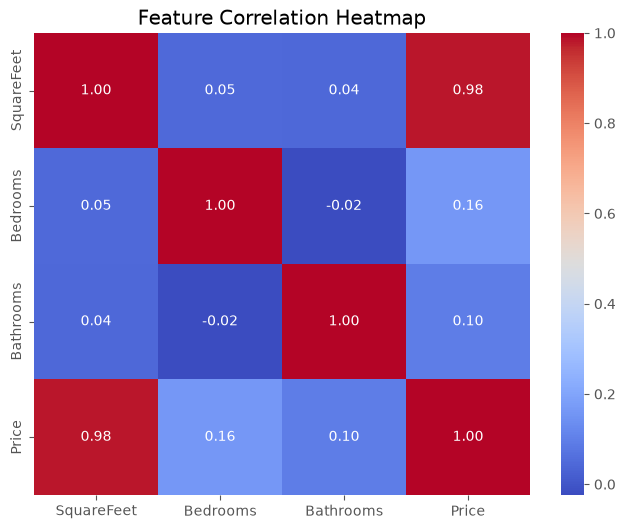

In [6]:
#corelation heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Heatmap')
plt.show()

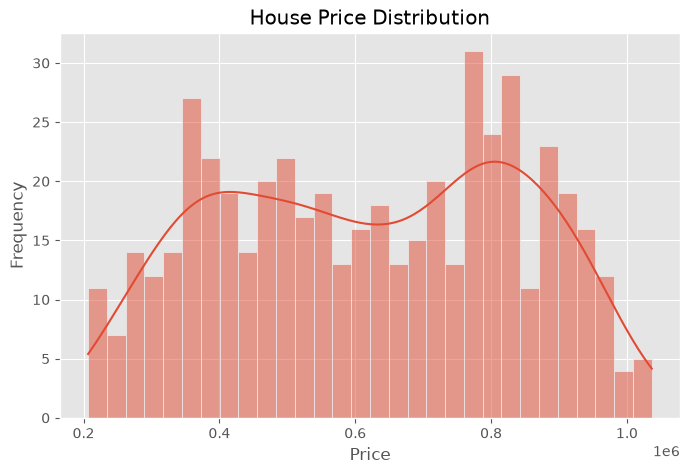

In [7]:
#House price distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df['Price'],
    kde=True,
    bins=30
)

plt.title('House Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.show()

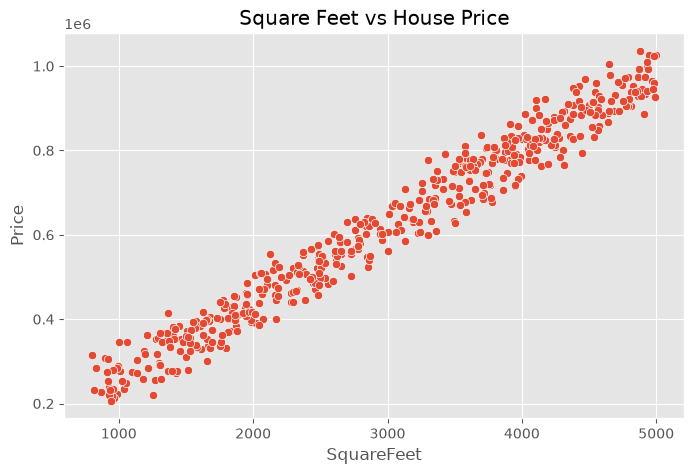

In [8]:
#Area Vs Price scatter plot
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['SquareFeet'],
    y=df['Price']
)

plt.title('Square Feet vs House Price')

plt.show()

In [9]:
#feature selection 
X = df[['SquareFeet', 'Bedrooms', 'Bathrooms']]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (400, 3)
Testing Data: (100, 3)


In [10]:
#train linear regression model
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [11]:
#predictions 
y_pred = model.predict(X_test)

pred_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

pred_df.head()

,Actual,Predicted
361,884066,882088.455949
73,226180,243821.122086
374,394170,416140.519676
155,806704,762024.796330
104,430281,384745.943331


In [12]:
#model evaluation 
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae,2))
print("MSE :", round(mse,2))
print("RMSE:", round(rmse,2))
print("R2 Score:", round(r2,4))

MAE : 25461.32
MSE : 850620559.41
RMSE: 29165.4
R2 Score: 0.9817


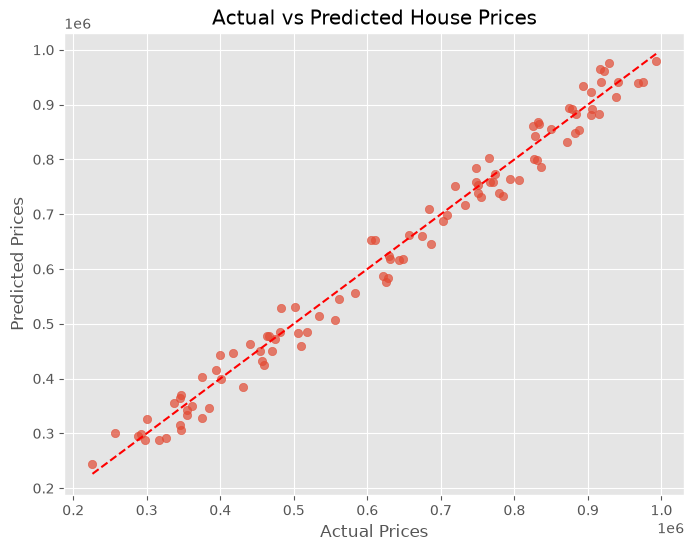

In [13]:
#actual vs predicted plot
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

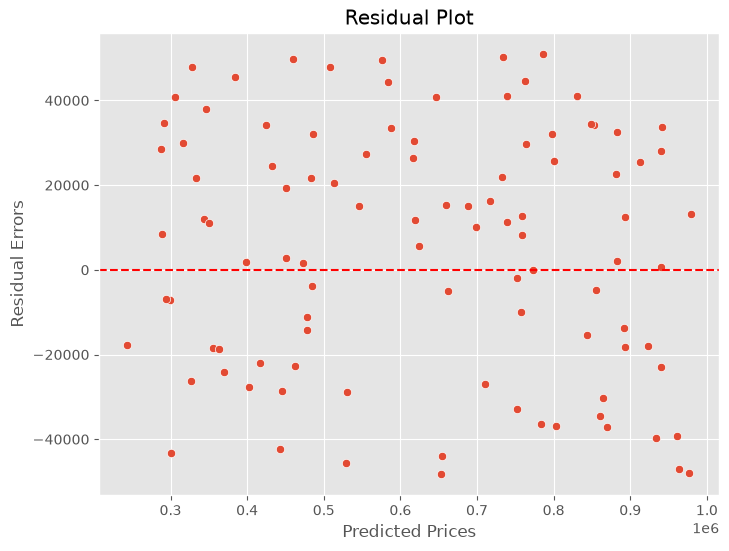

In [14]:
#residual analysis
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Prices")
plt.ylabel("Residual Errors")

plt.title("Residual Plot")

plt.show()

In [15]:
#Feature Importaance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

display(importance)

,Feature,Coefficient
1,Bedrooms,15023.043375
2,Bathrooms,11206.697614
0,SquareFeet,179.501105


In [16]:
#predict new house price
new_house = pd.DataFrame({
    'SquareFeet':[2500],
    'Bedrooms':[4],
    'Bathrooms':[3]
})

prediction = model.predict(new_house)

print(
    f"Predicted House Price: ₹{prediction[0]:,.2f}"
)

Predicted House Price: ₹544,875.28


In [20]:
#another prediction
new_house = pd.DataFrame({
    'SquareFeet':[3000],
    'Bedrooms':[5],
    'Bathrooms':[6]
})

prediction = model.predict(new_house)

print(
    f"Predicted House Price: ₹{prediction[0]:,.2f}"
)

Predicted House Price: ₹683,268.97
